# 🌿 Bellabeat Case Study — Limpieza y Transformación
## Plan completo paso a paso en Python

---

| Archivo fuente | Filas | Columnas clave |
|---|---|---|
| `dailyActivity_merged.csv` | 940 | Id, ActivityDate, TotalSteps, Calories, *Minutes, *Distance |
| `sleepDay_merged.csv` | 413 | Id, SleepDay *(timestamp)*, TotalMinutesAsleep, TotalTimeInBed |
| `hourlySteps_merged.csv` | 22 099 | Id, ActivityHour *(timestamp)*, StepTotal |
| `hourlyCalories_merged.csv` | 22 099 | Id, ActivityHour *(timestamp)*, Calories |
| `hourlyIntensities_merged.csv` | 22 099 | Id, ActivityHour *(timestamp)*, TotalIntensity, AverageIntensity |
| `weightLogInfo_merged.csv` | 67 | Id, Date *(timestamp)*, WeightKg, BMI, Fat, IsManualReport |
| `heartrate_seconds_merged.csv` | variable | Id, Time *(formato problemático)*, Value |

### Flujo de trabajo
```
0  Imports y configuración
1  Carga de datos
2  Exploración inicial
3  Auditoría de calidad  →  nulos · duplicados · outliers · inconsistencias
4  Limpieza              →  fechas · duplicados · registros inválidos · outliers
5  Feature engineering   →  variables temporales · clasificaciones · métricas
6  Tabla horaria unificada (steps + calories + intensities)
7  Tabla maestra diaria  (activity + sleep + weight + heartrate)
8  Validación final
9  Exportar
```


## 0 · Imports y Configuración

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import os, warnings

warnings.filterwarnings('ignore')

# Estilo global de gráficos
plt.rcParams.update({
    'figure.figsize'  : (13, 5),
    'axes.spines.top' : False,
    'axes.spines.right': False,
    'axes.grid'       : True,
    'grid.alpha'      : 0.3,
    'font.size'       : 11,
})
sns.set_palette('Set2')
pd.set_option('display.max_columns', 30)
pd.set_option('display.float_format', '{:.2f}'.format)

print("✅ Librerías listas  |  pandas", pd.__version__, " numpy", np.__version__)


✅ Librerías listas  |  pandas 3.0.1  numpy 2.4.3


## 1 · Carga de Datos

Ajusta `DATA_DIR` a la carpeta donde tienes los 7 CSV originales.  
Los archivos de fechas con hora (`SleepDay`, `ActivityHour`, `Date`, `Time`) se parsean  
en el paso 4 — aquí se cargan como texto para no perder información sobre el formato real.


In [3]:
DATA_DIR = '../data/raw'   # ← carpeta con los CSV originales de Fitbit (descargar de Kaggle)

activity   = pd.read_csv(os.path.join(DATA_DIR, 'dailyActivity_merged.csv'))
sleep      = pd.read_csv(os.path.join(DATA_DIR, 'sleepDay_merged.csv'))
h_steps    = pd.read_csv(os.path.join(DATA_DIR, 'hourlySteps_merged.csv'))
h_calories = pd.read_csv(os.path.join(DATA_DIR, 'hourlyCalories_merged.csv'))
h_intens   = pd.read_csv(os.path.join(DATA_DIR, 'hourlyIntensities_merged.csv'))
weight     = pd.read_csv(os.path.join(DATA_DIR, 'weightLogInfo_merged.csv'))
heartrate  = pd.read_csv(os.path.join(DATA_DIR, 'heartrate_seconds_merged.csv'))

tablas = {
    'activity'   : activity,
    'sleep'      : sleep,
    'h_steps'    : h_steps,
    'h_calories' : h_calories,
    'h_intens'   : h_intens,
    'weight'     : weight,
    'heartrate'  : heartrate,
}

print(f"{'Tabla':<14} {'Filas':>7}  {'Cols':>5}  Columnas")
print("-" * 70)
for nombre, df in tablas.items():
    print(f"{nombre:<14} {df.shape[0]:>7,}  {df.shape[1]:>5}  {list(df.columns)}")


Tabla            Filas   Cols  Columnas
----------------------------------------------------------------------
activity           940     15  ['Id', 'ActivityDate', 'TotalSteps', 'TotalDistance', 'TrackerDistance', 'LoggedActivitiesDistance', 'VeryActiveDistance', 'ModeratelyActiveDistance', 'LightActiveDistance', 'SedentaryActiveDistance', 'VeryActiveMinutes', 'FairlyActiveMinutes', 'LightlyActiveMinutes', 'SedentaryMinutes', 'Calories']
sleep              413      5  ['Id', 'SleepDay', 'TotalSleepRecords', 'TotalMinutesAsleep', 'TotalTimeInBed']
h_steps         22,099      3  ['Id', 'ActivityHour', 'StepTotal']
h_calories      22,099      3  ['Id', 'ActivityHour', 'Calories']
h_intens        22,099      4  ['Id', 'ActivityHour', 'TotalIntensity', 'AverageIntensity']
weight              67      8  ['Id', 'Date', 'WeightKg', 'WeightPounds', 'Fat', 'BMI', 'IsManualReport', 'LogId']
heartrate      2,483,658      3  ['Id', 'Time', 'Value']


## 2 · Exploración Inicial

In [5]:
# 2.1 Usuarios únicos por tabla
print("Usuarios únicos por tabla:")
for nombre, df in tablas.items():
    print(f"  {nombre:<14} → {df['Id'].nunique():>2} usuarios")


Usuarios únicos por tabla:
  activity       → 33 usuarios
  sleep          → 24 usuarios
  h_steps        → 33 usuarios
  h_calories     → 33 usuarios
  h_intens       → 33 usuarios
  weight         →  8 usuarios
  heartrate      → 14 usuarios


In [6]:
# 2.2 Vista rápida de las tablas principales
print("=== dailyActivity (primeras 3 filas) ===")
display(activity.head(3))


=== dailyActivity (primeras 3 filas) ===


,Id,ActivityDate,TotalSteps,TotalDistance,TrackerDistance,LoggedActivitiesDistance,VeryActiveDistance,ModeratelyActiveDistance,LightActiveDistance,SedentaryActiveDistance,VeryActiveMinutes,FairlyActiveMinutes,LightlyActiveMinutes,SedentaryMinutes,Calories
0,1503960366,4/12/2016,13162,8.50,8.50,0.00,1.88,0.55,6.06,0.00,25,13,328,728,1985
1,1503960366,4/13/2016,10735,6.97,6.97,0.00,1.57,0.69,4.71,0.00,21,19,217,776,1797
2,1503960366,4/14/2016,10460,6.74,6.74,0.00,2.44,0.40,3.91,0.00,30,11,181,1218,1776


In [7]:
print("=== sleepDay (primeras 3 filas) ===")
display(sleep.head(3))


=== sleepDay (primeras 3 filas) ===


,Id,SleepDay,TotalSleepRecords,TotalMinutesAsleep,TotalTimeInBed
0,1503960366,4/12/2016 12:00:00 AM,1,327,346
1,1503960366,4/13/2016 12:00:00 AM,2,384,407
2,1503960366,4/15/2016 12:00:00 AM,1,412,442


In [8]:
print("=== weightLogInfo (primeras 3 filas) ===")
display(weight.head(3))


=== weightLogInfo (primeras 3 filas) ===


,Id,Date,WeightKg,WeightPounds,Fat,BMI,IsManualReport,LogId
0,1503960366,5/2/2016 11:59:59 PM,52.60,115.96,22.00,22.65,True,1462233599000
1,1503960366,5/3/2016 11:59:59 PM,52.60,115.96,NaN,22.65,True,1462319999000
2,1927972279,4/13/2016 1:08:52 AM,133.50,294.32,NaN,47.54,False,1460509732000


In [9]:
print("=== heartrate_seconds (primeras 5 filas) ===")
display(heartrate.head(5))
print("\nTipo de la columna Time:", heartrate['Time'].dtype)
print("Ejemplo de valor    :", heartrate['Time'].iloc[0])


=== heartrate_seconds (primeras 5 filas) ===


,Id,Time,Value
0,2022484408,4/12/2016 7:21:00 AM,97
1,2022484408,4/12/2016 7:21:05 AM,102
2,2022484408,4/12/2016 7:21:10 AM,105
3,2022484408,4/12/2016 7:21:20 AM,103
4,2022484408,4/12/2016 7:21:25 AM,101



Tipo de la columna Time: str
Ejemplo de valor    : 4/12/2016 7:21:00 AM


In [10]:
# 2.3 Tipos de datos actuales
print("=== Tipos — dailyActivity ===")
print(activity.dtypes.to_string())


=== Tipos — dailyActivity ===
Id                            int64
ActivityDate                    str
TotalSteps                    int64
TotalDistance               float64
TrackerDistance             float64
LoggedActivitiesDistance    float64
VeryActiveDistance          float64
ModeratelyActiveDistance    float64
LightActiveDistance         float64
SedentaryActiveDistance     float64
VeryActiveMinutes             int64
FairlyActiveMinutes           int64
LightlyActiveMinutes          int64
SedentaryMinutes              int64
Calories                      int64


In [11]:
# 2.4 Estadísticas descriptivas — actividad
display(activity[['TotalSteps','TotalDistance','Calories',
                  'VeryActiveMinutes','FairlyActiveMinutes',
                  'LightlyActiveMinutes','SedentaryMinutes']].describe().T.round(1))


,count,mean,std,min,25%,50%,75%,max
TotalSteps,940.00,7637.90,5087.20,0.00,3789.80,7405.50,10727.00,36019.00
TotalDistance,940.00,5.50,3.90,0.00,2.60,5.20,7.70,28.00
Calories,940.00,2303.60,718.20,0.00,1828.50,2134.00,2793.20,4900.00
VeryActiveMinutes,940.00,21.20,32.80,0.00,0.00,4.00,32.00,210.00
FairlyActiveMinutes,940.00,13.60,20.00,0.00,0.00,6.00,19.00,143.00
LightlyActiveMinutes,940.00,192.80,109.20,0.00,127.00,199.00,264.00,518.00
SedentaryMinutes,940.00,991.20,301.30,0.00,729.80,1057.50,1229.50,1440.00


## 3 · Auditoría de Calidad
Detectamos todos los problemas **antes** de modificar nada.


### 3.1 Valores Nulos

In [12]:
def audit_nulos(df, nombre):
    n = df.isnull().sum()
    p = n / len(df) * 100
    t = pd.DataFrame({'nulos': n, '%': p}).query('nulos > 0')
    if t.empty:
        print(f"✅  {nombre}: sin valores nulos")
    else:
        print(f"⚠️   {nombre}:")
        display(t.round(1))

for nombre, df in tablas.items():
    audit_nulos(df, nombre)


✅  activity: sin valores nulos
✅  sleep: sin valores nulos
✅  h_steps: sin valores nulos
✅  h_calories: sin valores nulos
✅  h_intens: sin valores nulos
⚠️   weight:


,nulos,%
Fat,65,97.00


✅  heartrate: sin valores nulos


### 3.2 Duplicados

In [13]:
# Duplicados exactos (todas las columnas)
print("Duplicados exactos:")
for nombre, df in tablas.items():
    n = df.duplicated().sum()
    icon = '⚠️ ' if n > 0 else '✅'
    print(f"  {icon} {nombre:<14}: {n}")

print()

Duplicados exactos:
  ✅ activity      : 0
  ⚠️  sleep         : 3
  ✅ h_steps       : 0
  ✅ h_calories    : 0
  ✅ h_intens      : 0
  ✅ weight        : 0
  ✅ heartrate     : 0



In [14]:

# Duplicados lógicos (misma persona + mismo momento)
checks = [
    ('activity',   ['Id','ActivityDate']),
    ('sleep',      ['Id','SleepDay']),
    ('h_steps',    ['Id','ActivityHour']),
    ('h_calories', ['Id','ActivityHour']),
    ('h_intens',   ['Id','ActivityHour']),
    ('weight',     ['Id','Date']),
    ('heartrate',  ['Id','Time']),
]
print("Duplicados lógicos (Id + fecha/hora):")
for nombre, cols in checks:
    df = tablas[nombre]
    n  = df.duplicated(subset=cols).sum()
    icon = '⚠️ ' if n > 0 else '✅'
    print(f"  {icon} {nombre:<14}: {n}")


Duplicados lógicos (Id + fecha/hora):
  ✅ activity      : 0
  ⚠️  sleep         : 3
  ✅ h_steps       : 0
  ✅ h_calories    : 0
  ✅ h_intens      : 0
  ✅ weight        : 0
  ✅ heartrate     : 0


### 3.3 Problema de Fecha en `heartrate_seconds_merged`

In [15]:
# El campo Time viene como texto con formato "M/D/YYYY HH:MM:SS AM/PM"
# Analizamos el formato exacto antes de parsear
print("Valores de muestra de Time:")
print(heartrate['Time'].head(10).to_string())
print()
print("¿Contiene AM/PM?:", heartrate['Time'].str.contains('AM|PM', na=False).any())
print("¿Contiene /    ?:", heartrate['Time'].str.contains('/', na=False).any())
print()


Valores de muestra de Time:
0    4/12/2016 7:21:00 AM
1    4/12/2016 7:21:05 AM
2    4/12/2016 7:21:10 AM
3    4/12/2016 7:21:20 AM
4    4/12/2016 7:21:25 AM
5    4/12/2016 7:22:05 AM
6    4/12/2016 7:22:10 AM
7    4/12/2016 7:22:15 AM
8    4/12/2016 7:22:20 AM
9    4/12/2016 7:22:25 AM

¿Contiene AM/PM?: True
¿Contiene /    ?: True



In [16]:
# Intentar parsear con el formato esperado
muestra = heartrate['Time'].iloc[0]
print(f"Ejemplo: '{muestra}'")
try:
    parsed = pd.to_datetime(muestra, format='%m/%d/%Y %I:%M:%S %p')
    print(f"✅ Parseo OK → {parsed}")
except Exception as e:
    print(f"❌ Error con formato %m/%d/%Y %I:%M:%S %p: {e}")
    # Probar con inferencia automática
    parsed = pd.to_datetime(muestra, infer_datetime_format=True)
    print(f"✅ Inferencia automática → {parsed}")


Ejemplo: '4/12/2016 7:21:00 AM'
✅ Parseo OK → 2016-04-12 07:21:00


In [17]:
heartrate['Time'].dtype


<StringDtype(na_value=nan)>

In [18]:
heartrate.info()


<class 'pandas.DataFrame'>
RangeIndex: 2483658 entries, 0 to 2483657
Data columns (total 3 columns):
 #   Column  Dtype
---  ------  -----
 0   Id      int64
 1   Time    str  
 2   Value   int64
dtypes: int64(2), str(1)
memory usage: 104.1 MB


### 3.4 Registro de Fechas en Otras Tablas

In [19]:
# sleepDay y las tres hourly usan formato "M/D/YYYY H:MM:SS AM"
# weight usa    "M/D/YYYY H:MM:SS PM"
# dailyActivity usa "M/D/YYYY" (sin hora)
ejemplos = {
    'ActivityDate (activity)' : activity['ActivityDate'].iloc[0],
    'SleepDay (sleep)'        : sleep['SleepDay'].iloc[0],
    'ActivityHour (h_steps)'  : h_steps['ActivityHour'].iloc[0],
    'Date (weight)'           : weight['Date'].iloc[0],
    'Time (heartrate)'        : heartrate['Time'].iloc[0],
}
print("Formatos de fecha encontrados:")
for col, val in ejemplos.items():
    print(f"  {col:<30} → '{val}'")



Formatos de fecha encontrados:
  ActivityDate (activity)        → '4/12/2016'
  SleepDay (sleep)               → '4/12/2016 12:00:00 AM'
  ActivityHour (h_steps)         → '4/12/2016 12:00:00 AM'
  Date (weight)                  → '5/2/2016 11:59:59 PM'
  Time (heartrate)               → '4/12/2016 7:21:00 AM'


### 3.5 Outliers en Pasos (IQR)

In [20]:
Q1  = activity['TotalSteps'].quantile(0.25)    #Q1 → el 25% de los valores están por debajo
Q3  = activity['TotalSteps'].quantile(0.75)    #Q3 → el 75% de los valores están por debajo
IQR = Q3 - Q1                                  #El IQR (Interquartile Range) mide la dispersión central.
lim_inf = Q1 - 3 * IQR
lim_sup = Q3 + 3 * IQR

outliers_pasos = activity[                     #Esto devuelve solo las filas donde los pasos están fuera de los límites.
    (activity['TotalSteps'] < lim_inf) |
    (activity['TotalSteps'] > lim_sup)
]

print(f"Q1={Q1:.0f}  Q3={Q3:.0f}  IQR={IQR:.0f}")             #Muestra los valores calculados
print(f"Límite inferior (Q1-3·IQR) : {lim_inf:.0f}")
print(f"Límite superior (Q3+3·IQR) : {lim_sup:.0f}")
print(f"Outliers extremos          : {len(outliers_pasos)} "  #cuenta cuantos outliners hay
      f"({len(outliers_pasos)/len(activity)*100:.1f}%)")
if len(outliers_pasos):
    display(outliers_pasos[['Id','ActivityDate','TotalSteps','Calories']].head(8))


Q1=3790  Q3=10727  IQR=6937
Límite inferior (Q1-3·IQR) : -17022
Límite superior (Q3+3·IQR) : 31539
Outliers extremos          : 1 (0.1%)


,Id,ActivityDate,TotalSteps,Calories
50,1624580081,5/1/2016,36019,2690


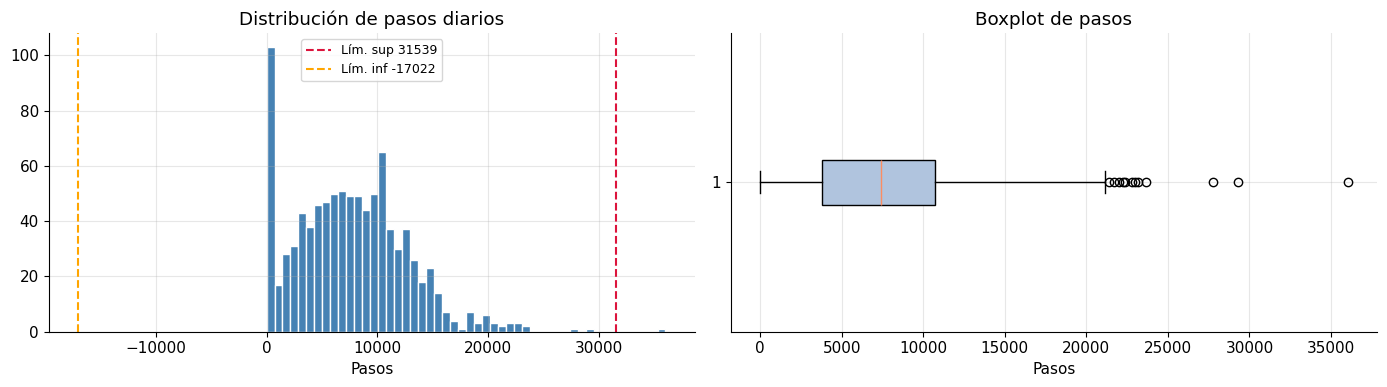

In [21]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 4))

ax1.hist(activity['TotalSteps'], bins=50, color='steelblue', edgecolor='white')
ax1.axvline(lim_sup, color='crimson', ls='--', lw=1.5, label=f'Lím. sup {lim_sup:.0f}')
ax1.axvline(lim_inf, color='orange',  ls='--', lw=1.5, label=f'Lím. inf {lim_inf:.0f}')
ax1.set_title('Distribución de pasos diarios'); ax1.set_xlabel('Pasos')
ax1.legend(fontsize=9)

ax2.boxplot(activity['TotalSteps'], vert=False, patch_artist=True,
            boxprops=dict(facecolor='lightsteelblue'))
ax2.set_title('Boxplot de pasos'); ax2.set_xlabel('Pasos')

plt.tight_layout(); plt.show()


## Conclusión final:
Los datos de pasos presentan una distribución natural con ligera asimetría hacia la derecha.
El método 3·IQR identifica únicamente unos pocos valores extremos por encima de ~31.500 pasos.
No existen outliers inferiores (el límite cae en valores negativos).
Los outliers superiores parecen plausibles y representan días de actividad muy elevada, no errores.
Se recomienda conservarlos, ya que aportan información sobre comportamientos intensos de ciertos usuarios.

### 3.6 Inconsistencias en Sueño

In [22]:
# Imposible: dormido > tiempo en cama
incons = sleep[sleep['TotalMinutesAsleep'] > sleep['TotalTimeInBed']]
print(f"Registros dormido > en cama : {len(incons)}")

# Sospechoso: 0 minutos dormidos
cero   = sleep[sleep['TotalMinutesAsleep'] == 0]
print(f"Registros con 0 min dormido : {len(cero)}")

# Eficiencia de sueño < 50 % (muy ineficiente)
sleep['_efic'] = sleep['TotalMinutesAsleep'] / sleep['TotalTimeInBed']
baja_efic = sleep[sleep['_efic'] < 0.5]
print(f"Registros con eficiencia <50%: {len(baja_efic)}")
sleep.drop(columns='_efic', inplace=True)


Registros dormido > en cama : 0
Registros con 0 min dormido : 0
Registros con eficiencia <50%: 1


### 3.7 Días sin Uso Real del Dispositivo

In [23]:
sin_uso = activity[(activity['TotalSteps'] == 0) & (activity['Calories'] == 0)]
print(f"Días con 0 pasos y 0 calorías (no llevó el dispositivo): {len(sin_uso)}")

# Suma de minutos > 1440 min/día (imposible)
activity['_sum_min'] = (activity['VeryActiveMinutes'] + activity['FairlyActiveMinutes']
                      + activity['LightlyActiveMinutes'] + activity['SedentaryMinutes'])
imposible = activity[activity['_sum_min'] > 1440]
print(f"Registros con suma minutos > 1440                     : {len(imposible)}")
activity.drop(columns='_sum_min', inplace=True)


Días con 0 pasos y 0 calorías (no llevó el dispositivo): 4
Registros con suma minutos > 1440                     : 0


#### 3.7.b Minutos sedentarios y calorias fuera del rango

In [24]:
# ============================================================
# 1. MINUTOS SEDENTARIOS > 1440 (imposible, más que minutos en un día)
# ============================================================
sedentario_imposible = activity[activity['SedentaryMinutes'] > 1440]
print(f"SedentaryMinutes > 1440 (imposible)                   : {len(sedentario_imposible)}")

# Bonus: cualquier categoría de minutos individual > 1440
minutos_cols = ['VeryActiveMinutes', 'FairlyActiveMinutes', 'LightlyActiveMinutes', 'SedentaryMinutes']
for col in minutos_cols:
    n = (activity[col] > 1440).sum()
    if n > 0:
        print(f"  ⚠️ {col:<20} > 1440: {n} registros")

SedentaryMinutes > 1440 (imposible)                   : 0


In [25]:

# ============================================================
# 2. CALORÍAS FUERA DE RANGO FISIOLÓGICO
# ============================================================
calorias_invalidas = activity[(activity['Calories'] <= 0) | (activity['Calories'] >= 10000)]
print(f"Calories fuera de rango (<=0 o >=10.000)              : {len(calorias_invalidas)}")

# Desglose por tipo de anomalía
print(f"  ├── Calories == 0                                     : {(activity['Calories'] == 0).sum()}")
print(f"  ├── Calories < 0                                      : {(activity['Calories'] < 0).sum()}")
print(f"  └── Calories >= 10.000                                : {(activity['Calories'] >= 10000).sum()}")



Calories fuera de rango (<=0 o >=10.000)              : 4
  ├── Calories == 0                                     : 4
  ├── Calories < 0                                      : 0
  └── Calories >= 10.000                                : 0


### 3.8 Cobertura por Usuario

Usuarios con < 7 días  : 1
Usuarios con < 14 días : 1
Mediana días/usuario   : 31
Min / Max              : 4 / 31


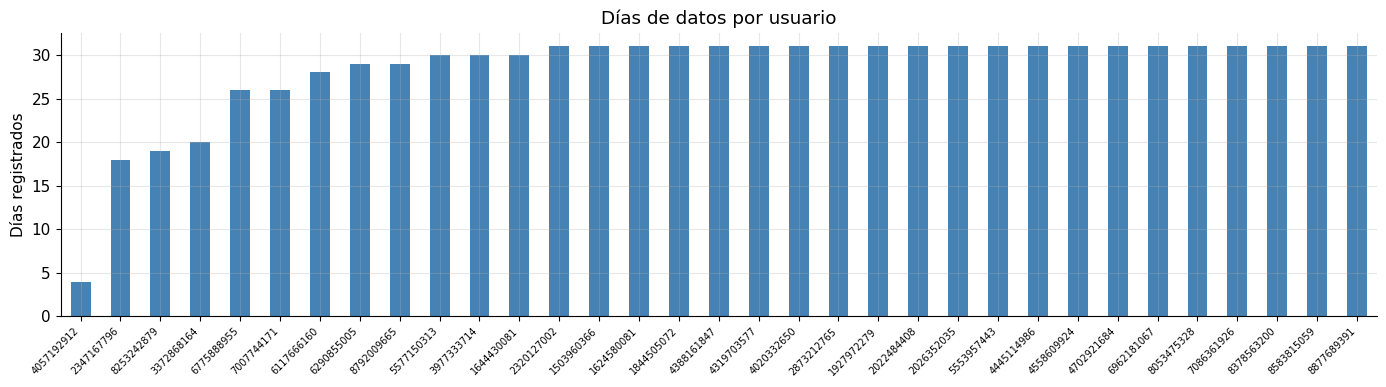

In [26]:
dias_usr = (activity.groupby('Id')['ActivityDate']
            .nunique().reset_index(name='dias')
            .sort_values('dias'))

print(f"Usuarios con < 7 días  : {(dias_usr['dias'] <  7).sum()}")
print(f"Usuarios con < 14 días : {(dias_usr['dias'] < 14).sum()}")
print(f"Mediana días/usuario   : {dias_usr['dias'].median():.0f}")
print(f"Min / Max              : {dias_usr['dias'].min()} / {dias_usr['dias'].max()}")

dias_usr['dias'].plot(kind='bar', figsize=(14, 4), color='steelblue',
    title='Días de datos por usuario', ylabel='Días registrados')
plt.xticks(range(len(dias_usr)), dias_usr['Id'].astype(str), rotation=45, ha='right', fontsize=7)
plt.tight_layout(); plt.show()


#### Análisis de días registrados por usuario
             
nunique() cuenta cuántos días distintos tiene cada usuario. Permite evaluar la completitud del dataset.

Usuarios con pocos días (<7 o <14) pueden distorsionar el análisis.

Métricas clave:
Mediana → días típicos por usuario
Min/Max → rango de participación

El gráfico de barras muestra visualmente qué usuarios tienen datos escasos.

Útil para decidir si excluir usuarios con baja actividad o analizarlos aparte.

## 4 · Limpieza
Trabajamos sobre **copias** de los DataFrames originales (`_raw` se conservan intactos).


### 4.1 Parseo de Fechas

In [5]:
act  = activity.copy()
slp  = sleep.copy()
hs   = h_steps.copy()
hc   = h_calories.copy()
hi   = h_intens.copy()
wgt  = weight.copy()
hr   = heartrate.copy()

# ── dailyActivity: formato "M/D/YYYY" ──────────────────────────────────────
act['ActivityDate'] = pd.to_datetime(act['ActivityDate'], format='%m/%d/%Y', errors='coerce')

# ── sleepDay: "M/D/YYYY H:MM:SS AM/PM" → solo fecha ──────────────────────
slp['SleepDay'] = (pd.to_datetime(slp['SleepDay'], format='%m/%d/%Y %I:%M:%S %p', errors='coerce')
                   .dt.normalize())
slp.rename(columns={'SleepDay': 'SleepDate'}, inplace=True)

# ── hourly (steps, calories, intensities): mismo timestamp ────────────────
FMT_HOUR = '%m/%d/%Y %I:%M:%S %p'
for df in [hs, hc, hi]:
    df['ActivityHour'] = pd.to_datetime(df['ActivityHour'], format=FMT_HOUR, errors='coerce')

# ── weightLogInfo: "M/D/YYYY H:MM:SS AM/PM" ──────────────────────────────
wgt['Date'] = pd.to_datetime(wgt['Date'], format='%m/%d/%Y %I:%M:%S %p', errors='coerce')

# ── heartrate_seconds: PROBLEMA CONOCIDO ─────────────────────────────────
# El campo Time a veces usa formato 12h (AM/PM) y a veces 24h.
# Estrategia: intentar formato estricto, fallback a inferencia automática.
print("Parseando heartrate_seconds (puede tardar unos segundos)...")
hr['Time'] = pd.to_datetime(hr['Time'], errors='coerce')

nulos_hr = hr['Time'].isnull().sum()
print(f"  Registros parseados OK : {len(hr) - nulos_hr:,}")
print(f"  Registros no parseados : {nulos_hr:,}")
if nulos_hr > 0:
    print("  ⚠️  Filas con Time nulo (muestra):")
    display(hr[hr['Time'].isnull()].head(5))

print()
print("Verificación de tipos tras parseo:")
for nombre, df, col in [
    ('activity',  act, 'ActivityDate'),
    ('sleep',     slp, 'SleepDate'),
    ('h_steps',   hs,  'ActivityHour'),
    ('weight',    wgt, 'Date'),
    ('heartrate', hr,  'Time'),
]:
    print(f"  {nombre:<12} {col:<15} → {df[col].dtype}")


Parseando heartrate_seconds (puede tardar unos segundos)...
  Registros parseados OK : 2,483,658
  Registros no parseados : 0

Verificación de tipos tras parseo:
  activity     ActivityDate    → datetime64[us]
  sleep        SleepDate       → datetime64[us]
  h_steps      ActivityHour    → datetime64[us]
  weight       Date            → datetime64[us]
  heartrate    Time            → datetime64[us]


### 4.2 Eliminar Duplicados

In [6]:
sizes_antes = {n: len(d) for n, d in [
    ('act',act),('slp',slp),('hs',hs),('hc',hc),('hi',hi),('wgt',wgt),('hr',hr)
]}

# Duplicados exactos
for df in [act, slp, hs, hc, hi, wgt, hr]:
    df.drop_duplicates(inplace=True)

# Duplicados lógicos
act.drop_duplicates(subset=['Id','ActivityDate'],  keep='first', inplace=True)
slp.drop_duplicates(subset=['Id','SleepDate'],     keep='first', inplace=True)
hs.drop_duplicates( subset=['Id','ActivityHour'],  keep='first', inplace=True)
hc.drop_duplicates( subset=['Id','ActivityHour'],  keep='first', inplace=True)
hi.drop_duplicates( subset=['Id','ActivityHour'],  keep='first', inplace=True)
wgt.drop_duplicates(subset=['Id','Date'],          keep='first', inplace=True)
hr.drop_duplicates( subset=['Id','Time'],          keep='first', inplace=True)

for d_name in ['act','slp','hs','hc','hi','wgt','hr']:
    df_now = locals()[d_name]
    diff   = sizes_antes[d_name] - len(df_now)
    icon   = '⚠️ ' if diff > 0 else '✅'
    print(f"  {icon} {d_name:<5}: eliminados {diff} duplicados → {len(df_now):,} filas restantes")


  ✅ act  : eliminados 0 duplicados → 940 filas restantes
  ⚠️  slp  : eliminados 3 duplicados → 410 filas restantes
  ✅ hs   : eliminados 0 duplicados → 22,099 filas restantes
  ✅ hc   : eliminados 0 duplicados → 22,099 filas restantes
  ✅ hi   : eliminados 0 duplicados → 22,099 filas restantes
  ✅ wgt  : eliminados 0 duplicados → 67 filas restantes
  ✅ hr   : eliminados 0 duplicados → 2,483,658 filas restantes


### 4.3 Filtrar Registros Inválidos

In [7]:
# activity: eliminar días sin uso real
mask_uso = ~((act['TotalSteps'] == 0) & (act['Calories'] == 0))
act = act[mask_uso].reset_index(drop=True)
print(f"Días sin uso eliminados       : {(~mask_uso).sum()}")

# activity: eliminar suma de minutos > 1440
sum_min = (act['VeryActiveMinutes'] + act['FairlyActiveMinutes']
         + act['LightlyActiveMinutes'] + act['SedentaryMinutes'])
mask_min = sum_min <= 1440
act = act[mask_min].reset_index(drop=True)
print(f"Registros con >1440 min elim. : {(~mask_min).sum()}")

# sleep: eliminar imposibles (dormido > en cama) y ceros
slp = slp[
    (slp['TotalMinutesAsleep'] <= slp['TotalTimeInBed']) &
    (slp['TotalMinutesAsleep'] > 0) &
    (slp['TotalTimeInBed']     > 0)
].reset_index(drop=True)
print(f"Filas sleep restantes         : {len(slp)}")

# heartrate: eliminar filas con Time nulo (no parseado)
hr = hr[hr['Time'].notna()].reset_index(drop=True)
print(f"Filas heartrate restantes     : {len(hr):,}")


Días sin uso eliminados       : 4
Registros con >1440 min elim. : 0
Filas sleep restantes         : 410
Filas heartrate restantes     : 2,483,658


### 4.4 Eliminar Outliers Extremos de Pasos (3·IQR)

In [8]:
Q1, Q3 = act['TotalSteps'].quantile([0.25, 0.75])
IQR    = Q3 - Q1

antes = len(act)
act = act[
    (act['TotalSteps'] >= Q1 - 3*IQR) &
    (act['TotalSteps'] <= Q3 + 3*IQR)
].reset_index(drop=True)

print(f"Outliers eliminados : {antes - len(act)}  |  filas restantes : {len(act)}")


Outliers eliminados : 1  |  filas restantes : 935


### 4.5 Excluir Usuarios con < 7 Días de Datos

In [9]:
usuarios_ok = (
    act.groupby('Id')['ActivityDate']
    .nunique()
    .loc[lambda s: s >= 7]
    .index
)

antes = {n: df['Id'].nunique() for n, df in [
    ('act',act),('slp',slp),('hs',hs),('hc',hc),('hi',hi),('hr',hr)
]}

act = act[act['Id'].isin(usuarios_ok)].reset_index(drop=True)
slp = slp[slp['Id'].isin(usuarios_ok)].reset_index(drop=True)
hs  = hs[ hs['Id'].isin(usuarios_ok)].reset_index(drop=True)
hc  = hc[ hc['Id'].isin(usuarios_ok)].reset_index(drop=True)
hi  = hi[ hi['Id'].isin(usuarios_ok)].reset_index(drop=True)
hr  = hr[ hr['Id'].isin(usuarios_ok)].reset_index(drop=True)
# weight y heartrate pueden tener muy pocos usuarios; se conservan todos

print(f"Usuarios válidos (≥7 días): {len(usuarios_ok)}")
for n, df, col in [('act',act,'ActivityDate'),('slp',slp,'SleepDate'),
                   ('hs',hs,'ActivityHour'),('hr',hr,'Time')]:
    print(f"  {n:<5}: {len(df):>6,} filas  |  {df['Id'].nunique()} usuarios")


Usuarios válidos (≥7 días): 32
  act  :    931 filas  |  32 usuarios
  slp  :    410 filas  |  24 usuarios
  hs   : 22,011 filas  |  32 usuarios
  hr   : 2,483,658 filas  |  14 usuarios


## 5 · Feature Engineering

### 5.1 Variables Temporales — `dailyActivity`

In [10]:
dias_es = {0:'Lunes',1:'Martes',2:'Miércoles',3:'Jueves',
           4:'Viernes',5:'Sábado',6:'Domingo'}

act['DiaSemana']     = act['ActivityDate'].dt.dayofweek.map(dias_es)
act['NumDiaSemana']  = act['ActivityDate'].dt.dayofweek        # 0=Lunes
act['EsFinSemana']   = act['NumDiaSemana'].isin([5,6]).astype(int)
act['Semana']        = act['ActivityDate'].dt.isocalendar().week.astype(int)
act['Mes']           = act['ActivityDate'].dt.month

print("✅ Variables temporales añadidas a activity")
display(act[['ActivityDate','DiaSemana','EsFinSemana','Semana']].head(4))


✅ Variables temporales añadidas a activity


,ActivityDate,DiaSemana,EsFinSemana,Semana
0,2016-04-12,Martes,0,15
1,2016-04-13,Miércoles,0,15
2,2016-04-14,Jueves,0,15
3,2016-04-15,Viernes,0,15


### 5.2 Clasificación de Actividad y Minutos OMS

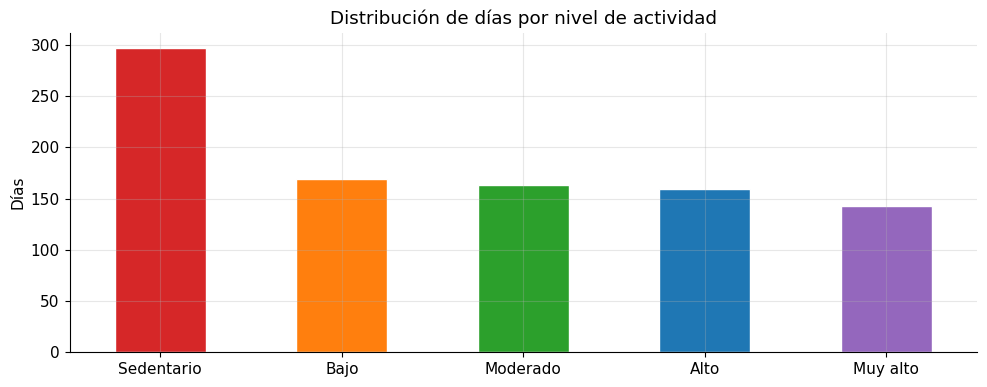

NivelActividad
Sedentario    297
Bajo          169
Moderado      163
Alto          159
Muy alto      143


In [13]:
# Nivel de actividad según pasos
bins   = [-1, 4999, 7499, 9999, 12499, float('inf')]
labels = ['Sedentario','Bajo','Moderado','Alto','Muy alto']
act['NivelActividad'] = pd.cut(act['TotalSteps'], bins=bins, labels=labels)

# Minutos actividad moderada+ (criterio OMS)
act['MinModeradaPlus'] = act['VeryActiveMinutes'] + act['FairlyActiveMinutes']

# Flag: cumple OMS diario ≥30 min moderada+
act['CumpleOMS_dia']  = (act['MinModeradaPlus'] >= 30).astype(int)

# Columna "registro válido" (dispositivo llevado ese día)
act['RegistroValido'] = 1   # ya filtramos los días sin uso en 4.3

orden = ['Sedentario','Bajo','Moderado','Alto','Muy alto']
dist  = act['NivelActividad'].value_counts().reindex(orden)
colores = ['#d62728','#ff7f0e','#2ca02c','#1f77b4','#9467bd']
dist.plot(kind='bar', color=colores, edgecolor='white', figsize=(10,4),
          title='Distribución de días por nivel de actividad')
plt.xlabel(''); plt.ylabel('Días'); plt.xticks(rotation=0); plt.tight_layout(); plt.show()
print(dist.to_string())


### 5.3 Variables de Sueño

In [14]:
slp['EficienciaSueno_Pct']  = (slp['TotalMinutesAsleep'] / slp['TotalTimeInBed'] * 100).round(1)
slp['MinDespierto_EnCama']  = slp['TotalTimeInBed'] - slp['TotalMinutesAsleep']

bins_s   = [-1, 359, 419, 539, 9999]
labels_s = ['Déficit grave (<6h)','Déficit leve (6-7h)','Óptimo (7-9h)','Excesivo (>9h)']
slp['CalidadSueno'] = pd.cut(slp['TotalMinutesAsleep'], bins=bins_s, labels=labels_s)

print("✅ Variables de sueño creadas")
display(slp[['Id','SleepDate','TotalMinutesAsleep','TotalTimeInBed',
             'EficienciaSueno_Pct','CalidadSueno']].head(4))


✅ Variables de sueño creadas


,Id,SleepDate,TotalMinutesAsleep,TotalTimeInBed,EficienciaSueno_Pct,CalidadSueno
0,1503960366,2016-04-12,327,346,94.50,Déficit grave (<6h)
1,1503960366,2016-04-13,384,407,94.30,Déficit leve (6-7h)
2,1503960366,2016-04-15,412,442,93.20,Déficit leve (6-7h)
3,1503960366,2016-04-16,340,367,92.60,Déficit grave (<6h)


### 5.4 Variables de Peso

In [15]:
# Categoría IMC (OMS)
bins_imc   = [-1, 18.5, 24.9, 29.9, float('inf')]
labels_imc = ['Bajo peso','Normal','Sobrepeso','Obesidad']
wgt['CategoriaIMC']   = pd.cut(wgt['BMI'], bins=bins_imc, labels=labels_imc)
wgt['TipoRegistro']   = wgt['IsManualReport'].map({True:'Manual', False:'Automático'})

print("✅ Variables de peso creadas")
display(wgt[['Id','Date','WeightKg','BMI','CategoriaIMC','TipoRegistro']].head(4))


✅ Variables de peso creadas


,Id,Date,WeightKg,BMI,CategoriaIMC,TipoRegistro
0,1503960366,2016-05-02 23:59:59,52.60,22.65,Normal,Manual
1,1503960366,2016-05-03 23:59:59,52.60,22.65,Normal,Manual
2,1927972279,2016-04-13 01:08:52,133.50,47.54,Obesidad,Automático
3,2873212765,2016-04-21 23:59:59,56.70,21.45,Normal,Manual


### 5.5 Variables Horarias (steps, calories, intensities)

In [16]:
for df in [hs, hc, hi]:
    df['Fecha']        = df['ActivityHour'].dt.date
    df['Hora']         = df['ActivityHour'].dt.hour
    df['FranjaHoraria'] = pd.cut(
        df['Hora'],
        bins=[-1, 5, 11, 17, 22, 23],
        labels=['Madrugada','Mañana','Tarde','Noche','Noche tardía']
    )

print("✅ Variables horarias añadidas a hs, hc, hi")
display(hs[['Id','ActivityHour','Fecha','Hora','FranjaHoraria','StepTotal']].head(4))


✅ Variables horarias añadidas a hs, hc, hi


,Id,ActivityHour,Fecha,Hora,FranjaHoraria,StepTotal
0,1503960366,2016-04-12 00:00:00,2016-04-12,0,Madrugada,373
1,1503960366,2016-04-12 01:00:00,2016-04-12,1,Madrugada,160
2,1503960366,2016-04-12 02:00:00,2016-04-12,2,Madrugada,151
3,1503960366,2016-04-12 03:00:00,2016-04-12,3,Madrugada,0


### 5.6 Agrupación de Heartrate a Nivel Diario

In [17]:
# El archivo tiene una fila por segundo → lo agrupamos a nivel diario
# para poder unirlo con las demás tablas
hr['Fecha'] = hr['Time'].dt.date

hr_daily = (
    hr.groupby(['Id','Fecha'])
    .agg(
        FC_Media   = ('Value', 'mean'),
        FC_Minima  = ('Value', 'min'),
        FC_Maxima  = ('Value', 'max'),
        FC_Std     = ('Value', 'std'),
        Mediciones = ('Value', 'count'),
    )
    .reset_index()
    .rename(columns={'Fecha':'ActivityDate'})
)
hr_daily['ActivityDate'] = pd.to_datetime(hr_daily['ActivityDate'])
hr_daily['FC_Media']     = hr_daily['FC_Media'].round(1)
hr_daily['FC_Std']       = hr_daily['FC_Std'].round(1)

print(f"✅ heartrate agrupado a diario: {len(hr_daily)} filas | {hr_daily['Id'].nunique()} usuarios")
display(hr_daily.head(4))


✅ heartrate agrupado a diario: 334 filas | 14 usuarios


,Id,ActivityDate,FC_Media,FC_Minima,FC_Maxima,FC_Std,Mediciones
0,2022484408,2016-04-12,75.80,52,134,16.30,4836
1,2022484408,2016-04-13,80.30,51,156,18.20,5332
2,2022484408,2016-04-14,72.60,50,127,13.50,5560
3,2022484408,2016-04-15,80.40,53,189,17.90,5302


## 6 · Tabla Horaria Unificada
Unimos `hourlySteps` + `hourlyCalories` + `hourlyIntensities` en un solo DataFrame.


In [18]:
# Los tres archivos tienen exactamente los mismos Id × ActivityHour
df_hourly = (
    hs[['Id','ActivityHour','Fecha','Hora','FranjaHoraria','StepTotal']]
    .merge(hc[['Id','ActivityHour','Calories']],       on=['Id','ActivityHour'], how='inner')
    .merge(hi[['Id','ActivityHour','TotalIntensity','AverageIntensity']],
                                                        on=['Id','ActivityHour'], how='inner')
)

print(f"✅ df_hourly: {df_hourly.shape}")
display(df_hourly.head(4))


✅ df_hourly: (22011, 9)


,Id,ActivityHour,Fecha,Hora,FranjaHoraria,StepTotal,Calories,TotalIntensity,AverageIntensity
0,1503960366,2016-04-12 00:00:00,2016-04-12,0,Madrugada,373,81,20,0.33
1,1503960366,2016-04-12 01:00:00,2016-04-12,1,Madrugada,160,61,8,0.13
2,1503960366,2016-04-12 02:00:00,2016-04-12,2,Madrugada,151,59,7,0.12
3,1503960366,2016-04-12 03:00:00,2016-04-12,3,Madrugada,0,47,0,0.00


## 7 · Tabla Maestra Diaria
Unimos actividad + sueño + peso + frecuencia cardíaca con LEFT JOIN  
(se conservan todos los días de `activity` aunque no haya registro en las otras tablas).


In [19]:
# Preparar claves de join
slp_join = slp.rename(columns={'SleepDate':'ActivityDate'})
wgt_join = wgt.copy()
wgt_join['ActivityDate'] = pd.to_datetime(wgt_join['Date'].dt.date)

df_master = (
    act
    .merge(slp_join[['Id','ActivityDate','TotalSleepRecords','TotalMinutesAsleep',
                      'TotalTimeInBed','EficienciaSueno_Pct',
                      'MinDespierto_EnCama','CalidadSueno']],
           on=['Id','ActivityDate'], how='left')
    .merge(wgt_join[['Id','ActivityDate','WeightKg','BMI','CategoriaIMC','TipoRegistro']],
           on=['Id','ActivityDate'], how='left')
    .merge(hr_daily[['Id','ActivityDate','FC_Media','FC_Minima','FC_Maxima','FC_Std']],
           on=['Id','ActivityDate'], how='left')
)

# Flags de cobertura
df_master['TieneSueno'] = df_master['TotalMinutesAsleep'].notna().astype(int)
df_master['TienePeso']  = df_master['WeightKg'].notna().astype(int)
df_master['TieneFC']    = df_master['FC_Media'].notna().astype(int)

print(f"✅ df_master: {df_master.shape}")
print(f"   Usuarios : {df_master['Id'].nunique()}")
print(f"   Cobertura sueño : {df_master['TieneSueno'].mean()*100:.1f}%")
print(f"   Cobertura peso  : {df_master['TienePeso'].mean()*100:.1f}%")
print(f"   Cobertura FC    : {df_master['TieneFC'].mean()*100:.1f}%")
display(df_master.head(4))


✅ df_master: (931, 41)
   Usuarios : 32
   Cobertura sueño : 44.0%
   Cobertura peso  : 7.2%
   Cobertura FC    : 35.9%


,Id,ActivityDate,TotalSteps,TotalDistance,TrackerDistance,LoggedActivitiesDistance,VeryActiveDistance,ModeratelyActiveDistance,LightActiveDistance,SedentaryActiveDistance,VeryActiveMinutes,FairlyActiveMinutes,LightlyActiveMinutes,SedentaryMinutes,Calories,...,TotalTimeInBed,EficienciaSueno_Pct,MinDespierto_EnCama,CalidadSueno,WeightKg,BMI,CategoriaIMC,TipoRegistro,FC_Media,FC_Minima,FC_Maxima,FC_Std,TieneSueno,TienePeso,TieneFC
0,1503960366,2016-04-12,13162,8.50,8.50,0.00,1.88,0.55,6.06,0.00,25,13,328,728,1985,...,346.00,94.50,19.00,Déficit grave (<6h),NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1,0,0
1,1503960366,2016-04-13,10735,6.97,6.97,0.00,1.57,0.69,4.71,0.00,21,19,217,776,1797,...,407.00,94.30,23.00,Déficit leve (6-7h),NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1,0,0
2,1503960366,2016-04-14,10460,6.74,6.74,0.00,2.44,0.40,3.91,0.00,30,11,181,1218,1776,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0,0,0
3,1503960366,2016-04-15,9762,6.28,6.28,0.00,2.14,1.26,2.83,0.00,29,34,209,726,1745,...,442.00,93.20,30.00,Déficit leve (6-7h),NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1,0,0


In [20]:
# Segmentación de usuarios (como en el script SQL bellabeat_05_master_table)
bins_seg   = [-1, 4999, 7499, 9999, float('inf')]
labels_seg = ['Sedentario (<5k)','Moderado (5-7.5k)','Activo (7.5-10k)','Muy activo (≥10k)']

user_seg = (
    df_master.groupby('Id')
    .agg(
        MediaPasos      = ('TotalSteps', 'mean'),
        MediaCalorias   = ('Calories',   'mean'),
        DiasConDatos    = ('ActivityDate','count'),
        DiasConSueno    = ('TieneSueno', 'sum'),
        DiasConFC       = ('TieneFC',    'sum'),
        DiasConPeso     = ('TienePeso',  'sum'),
    )
    .reset_index()
)
user_seg['Segmento'] = pd.cut(user_seg['MediaPasos'], bins=bins_seg, labels=labels_seg)

print("Distribución de segmentos:")
display(user_seg['Segmento'].value_counts().to_frame())


Distribución de segmentos:


,count
Segmento,
Activo (7.5-10k),9
Sedentario (<5k),8
Moderado (5-7.5k),8
Muy activo (≥10k),7


## 8 · Validación Final

In [21]:
print("=" * 60)
print("RESUMEN TABLAS LIMPIAS")
print("=" * 60)
resumen = {
    'df_master'  : df_master,
    'df_hourly'  : df_hourly,
    'slp (clean)': slp,
    'wgt (clean)': wgt,
    'hr_daily'   : hr_daily,
}
for nombre, df in resumen.items():
    n_nulos = df.isnull().sum().sum()
    print(f"  {nombre:<15}: {len(df):>7,} filas | {df['Id'].nunique():>2} usuarios | "
          f"{n_nulos:>5} nulos totales")


RESUMEN TABLAS LIMPIAS
  df_master      :     931 filas | 32 usuarios |  8970 nulos totales
  df_hourly      :  22,011 filas | 32 usuarios |     0 nulos totales
  slp (clean)    :     410 filas | 24 usuarios |     0 nulos totales
  wgt (clean)    :      67 filas |  8 usuarios |    65 nulos totales
  hr_daily       :     334 filas | 14 usuarios |     0 nulos totales


In [22]:
# Estadísticas finales de df_master
print("=== Estadísticas — df_master ===")
cols_stats = ['TotalSteps','Calories','VeryActiveMinutes','SedentaryMinutes',
              'TotalMinutesAsleep','WeightKg','FC_Media']
display(df_master[cols_stats].describe().T.round(1))


=== Estadísticas — df_master ===


,count,mean,std,min,25%,50%,75%,max
TotalSteps,931.00,7656.60,4992.70,0.00,3815.00,7451.00,10734.00,29326.00
Calories,931.00,2314.50,704.80,52.00,1836.00,2140.00,2796.50,4900.00
VeryActiveMinutes,931.00,21.20,32.50,0.00,0.00,4.00,32.00,210.00
SedentaryMinutes,931.00,988.30,300.60,0.00,728.50,1057.00,1223.50,1440.00
TotalMinutesAsleep,410.00,419.20,118.60,58.00,361.00,432.50,490.00,796.00
WeightKg,67.00,72.00,13.90,52.60,61.40,62.50,85.00,133.50
FC_Media,334.00,78.60,10.60,59.40,70.50,77.40,85.00,109.80


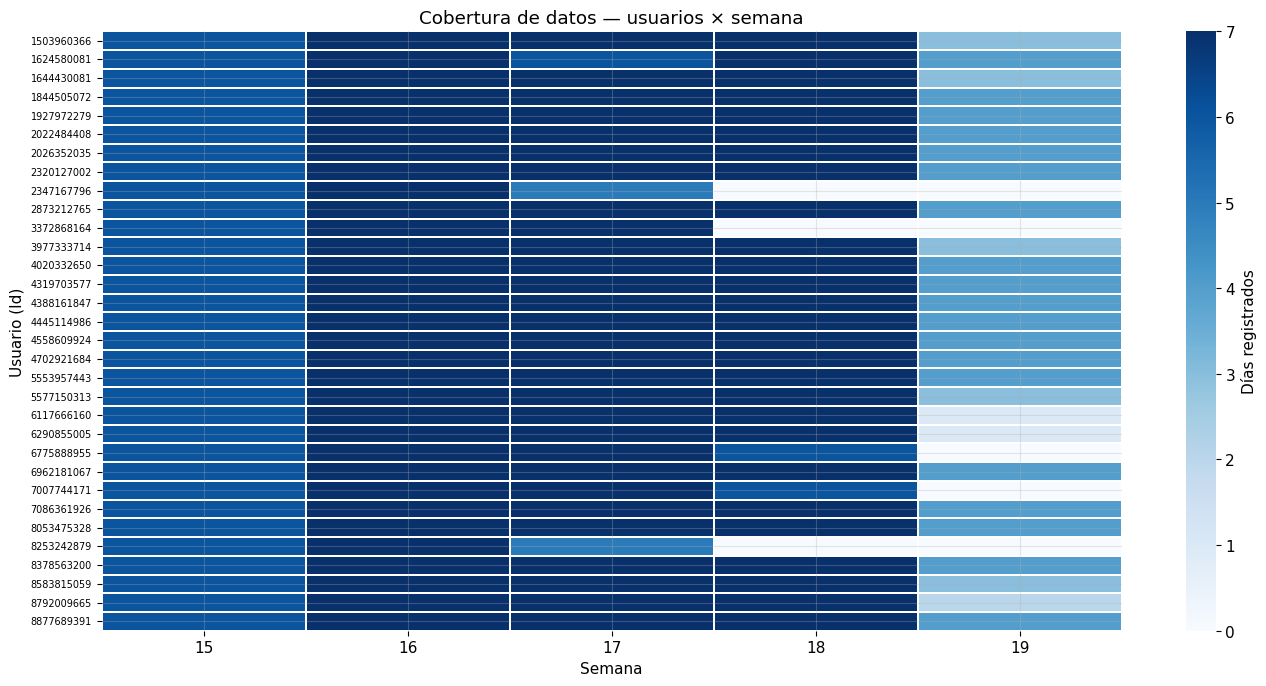

In [23]:
# Heatmap de cobertura: usuarios × semana
pivot = (
    df_master.groupby(['Id','Semana'])['TotalSteps']
    .count().unstack(fill_value=0)
)
plt.figure(figsize=(14, 7))
sns.heatmap(pivot, cmap='Blues', linewidths=0.3,
            cbar_kws={'label':'Días registrados'})
plt.title('Cobertura de datos — usuarios × semana')
plt.xlabel('Semana'); plt.ylabel('Usuario (Id)')
plt.yticks(fontsize=7); plt.tight_layout(); plt.show()


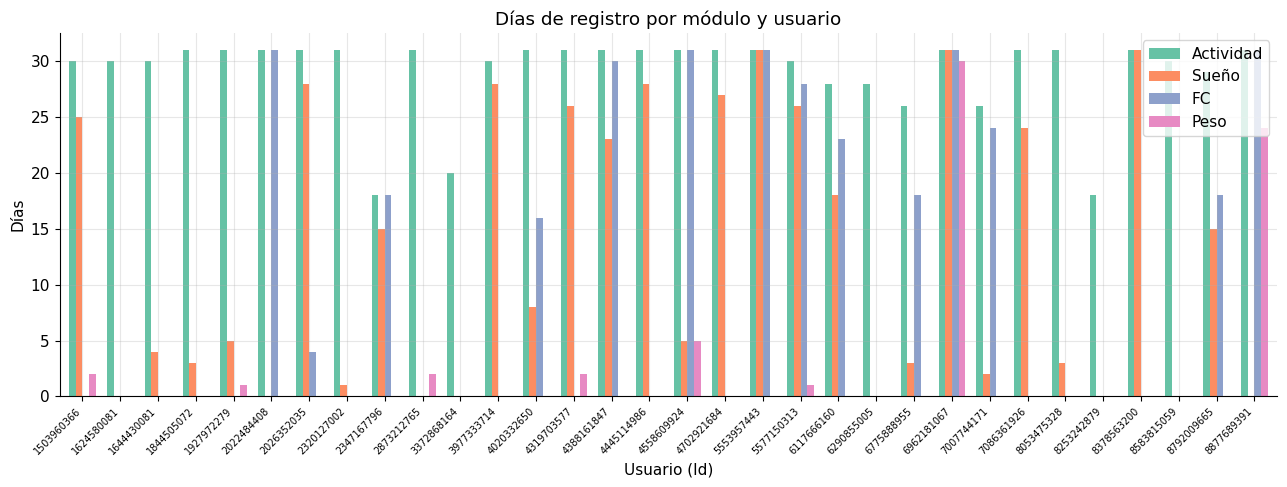

In [24]:
# Cobertura de módulos por usuario
fig, ax = plt.subplots(figsize=(13, 5))
seg_cob = user_seg.set_index('Id')[['DiasConDatos','DiasConSueno','DiasConFC','DiasConPeso']]
seg_cob.plot(kind='bar', ax=ax, width=0.7)
ax.set_title('Días de registro por módulo y usuario')
ax.set_xlabel('Usuario (Id)'); ax.set_ylabel('Días')
ax.legend(['Actividad','Sueño','FC','Peso'], loc='upper right')
plt.xticks(rotation=45, ha='right', fontsize=7)
plt.tight_layout(); plt.show()


## 9 · Exportar Datos Limpios

In [25]:
OUT = './data_clean'
os.makedirs(OUT, exist_ok=True)

exports = {
    'master_daily.csv'       : df_master,
    'hourly_unified.csv'     : df_hourly,
    'sleep_clean.csv'        : slp,
    'weight_clean.csv'       : wgt,
    'heartrate_daily.csv'    : hr_daily,
    'user_segments.csv'      : user_seg,
}

for fname, df in exports.items():
    path = os.path.join(OUT, fname)
    df.to_csv(path, index=False)
    print(f"  ✅ {fname:<30} → {len(df):,} filas")

print()
print("🚀 Datos limpios en ./data_clean/")
print("   Siguiente paso: bellabeat_eda.ipynb")


  ✅ master_daily.csv               → 931 filas
  ✅ hourly_unified.csv             → 22,011 filas
  ✅ sleep_clean.csv                → 410 filas
  ✅ weight_clean.csv               → 67 filas
  ✅ heartrate_daily.csv            → 334 filas
  ✅ user_segments.csv              → 32 filas

🚀 Datos limpios en ./data_clean/
   Siguiente paso: bellabeat_eda.ipynb
